## **Data Set Loading**

In [ ]:
import pandas as pd
child = pd.read_csv("Autism_Child_Data.csv")
adult = pd.read_csv("Autism_Adult_Data.csv")
adolescent = pd.read_csv("Autism_Adolescent_Data.csv")
screening = pd.read_csv("Toddler Autism dataset July 2018.csv")

In [ ]:
print("Child:", child.columns.tolist())
print("Adult:", adult.columns.tolist())
print("Adolescent:", adolescent.columns.tolist())
print("Screening:", screening.columns.tolist())


Child: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Adult: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Adolescent: ['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']
Screening: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the 

In [ ]:
print("Child dataset:", child.shape)
print("Adult dataset:", adult.shape)
print("Adolescent dataset:", adolescent.shape)
print("Screening dataset:", screening.shape)

Child dataset: (292, 22)
Adult dataset: (704, 22)
Adolescent dataset: (104, 22)
Screening dataset: (1054, 19)


In [ ]:
print("Child dataset:", child['Class/ASD'].value_counts())
print("Adult dataset:", adult['Class/ASD'].value_counts())
print("Adolescent dataset:", adolescent['Class/ASD'].value_counts())
print("Screening dataset:", screening['Class/ASD Traits '].value_counts())

Child dataset: Class/ASD
NO     151
YES    141
Name: count, dtype: int64
Adult dataset: Class/ASD
NO     515
YES    189
Name: count, dtype: int64
Adolescent dataset: Class/ASD
YES    63
NO     41
Name: count, dtype: int64
Screening dataset: Class/ASD Traits 
Yes    728
No     326
Name: count, dtype: int64


# **Data Preprocessing**

# [**Common Feature Selection**]

In [ ]:
screening.rename(columns={
    'A1': 'A1_Score',
    'A2': 'A2_Score',
    'A3': 'A3_Score',
    'A4': 'A4_Score',
    'A5': 'A5_Score',
    'A6': 'A6_Score',
    'A7': 'A7_Score',
    'A8': 'A8_Score',
    'A9': 'A9_Score',
    'A10': 'A10_Score',
    'Sex': 'gender',
    'Ethnicity': 'ethnicity',
    'Jaundice': 'jundice',
    'Family_mem_with_ASD': 'austim',
    'Class/ASD Traits ': 'Class/ASD'
}, inplace=True)


In [ ]:
screening["age"] = screening["Age_Mons"] / 12

In [ ]:
selected_cols = [
    'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score',
    'age','gender','ethnicity','jundice','austim',
    'Class/ASD'
]

In [ ]:
child = child[selected_cols]
adult = adult[selected_cols]
adolescent = adolescent[selected_cols]
screening = screening[selected_cols]

In [ ]:

print("Child:", child.shape)
print("Adult:", adult.shape)
print("Adolescent:", adolescent.shape)
print("Screening:", screening.shape)

Child: (292, 16)
Adult: (704, 16)
Adolescent: (104, 16)
Screening: (1054, 16)


# **Dataset Merging**

In [ ]:

child['source'] = 'child'
adult['source'] = 'adult'
adolescent['source'] = 'adolescent'
screening['source'] = 'screening'

combined = pd.concat([child, adult, adolescent, screening], ignore_index=True)
df = combined

In [ ]:
df=combined
print("\nShape:")
print(df.shape)


Shape:
(2154, 17)


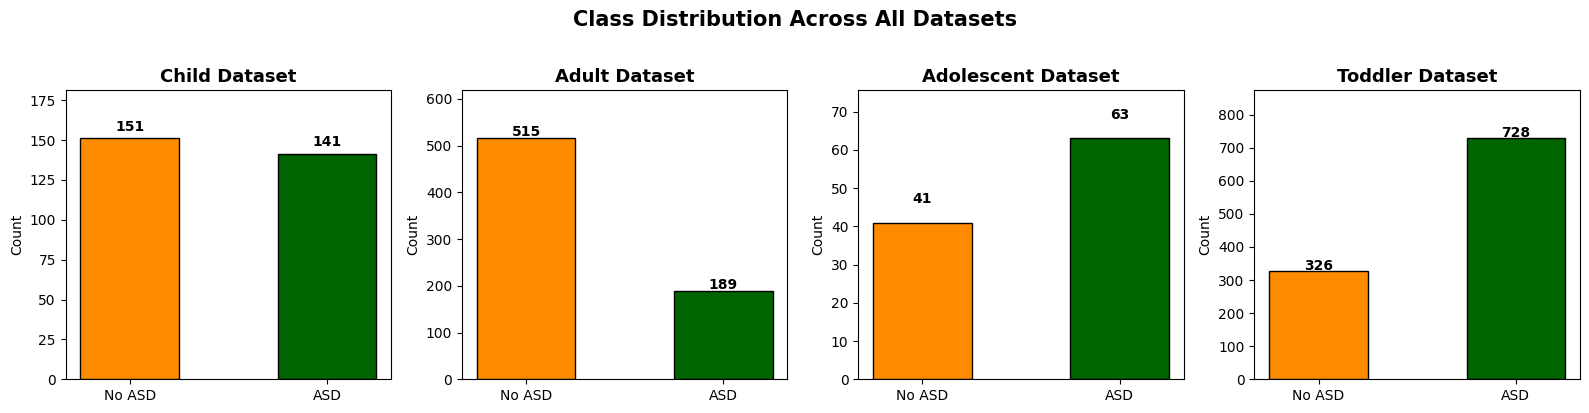

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
datasets = {'Child': child, 'Adult': adult, 'Adolescent': adolescent, 'Toddler': screening}
colors = ['#ff8c00', '#006400']
for ax, (name, ds) in zip(axes, datasets.items()):
    counts = ds['Class/ASD'].value_counts().sort_index()
    labels = ['No ASD', 'ASD']
    ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{name} Dataset', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
fig.suptitle('Class Distribution Across All Datasets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
A1_Score     0
A2_Score     0
A3_Score     0
A4_Score     0
A5_Score     0
A6_Score     0
A7_Score     0
A8_Score     0
A9_Score     0
A10_Score    0
age          0
gender       0
ethnicity    0
jundice      0
austim       0
Class/ASD    0
source       0
dtype: int64


In [ ]:
import pandas as pd
print("Before cleaning:")
print(df["Class/ASD"].value_counts())
df["Class/ASD"] = (
    df["Class/ASD"]
    .astype(str)
    .str.strip()
    .str.upper()
)
print("\nAfter fixing target labels:")
print(df["Class/ASD"].value_counts())
df["ethnicity"] = df["ethnicity"].replace("?", pd.NA)
df["ethnicity"]=df["ethnicity"].fillna(df["ethnicity"].mode()[0])
for col in ["gender", "jundice", "austim"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

Before cleaning:
Class/ASD
Yes    728
NO     707
YES    393
No     326
Name: count, dtype: int64

After fixing target labels:
Class/ASD
YES    1121
NO     1033
Name: count, dtype: int64


import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Class/ASD' column is numerical (0 or 1) before plotting
# This mapping is crucial because colors_map and labels_map use integer keys
df["Class/ASD"] = df["Class/ASD"].map({"NO": 0, "YES": 1})

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {0: '#4CAF50', 1: '#F44336'}
labels_map = {0: 'No ASD', 1: 'ASD'}

for label, grp in df.groupby('Class/ASD'):
    sns.kdeplot(grp['age'], ax=ax, fill=True, alpha=0.4,
                color=colors_map[label], label=labels_map[label])

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Age Distribution by ASD Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig2_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
count_q = (df["age"] == "?").sum()
print("Number of '?' in age:", count_q)
print("Total rows:", len(df))
print("Percentage:", (count_q / len(df)) * 100)

Number of '?' in age: 6
Total rows: 2154
Percentage: 0.2785515320334262


In [ ]:
df = df[df["age"] != "?"]
df.loc[:, "age"] = pd.to_numeric(df["age"])
print("Rows after removal:", df.shape)

Rows after removal: (2148, 17)


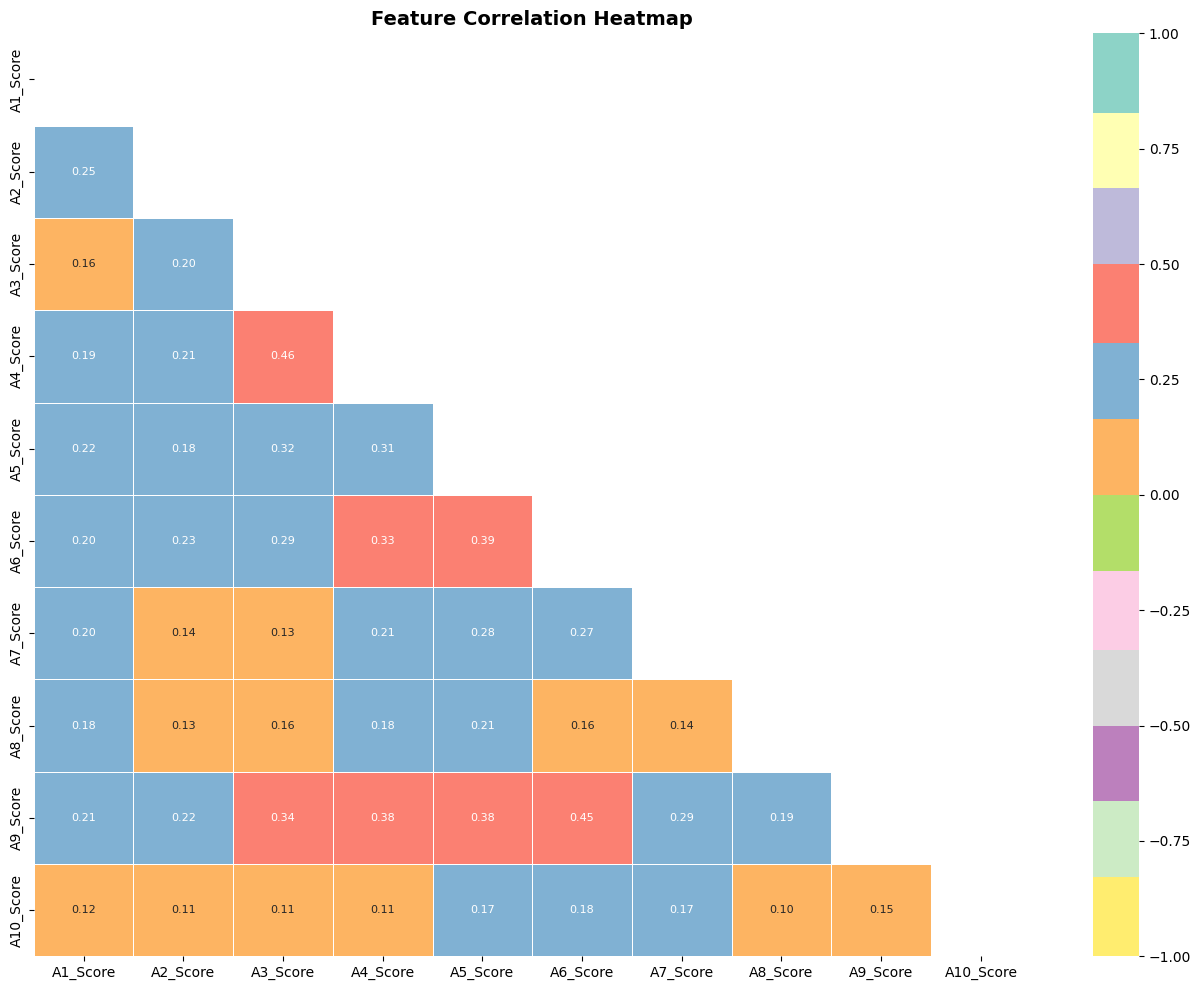

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.drop(columns=['source'], errors='ignore').select_dtypes(include='number')
corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = __import__('numpy').triu(__import__('numpy').ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Set3_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1, center=0)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include="object").columns
label_encoders = {}
for col in categorical_cols:
    if col != "Class/ASD" and col !="source":
        le = LabelEncoder()
        df.loc[:, col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [ ]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,Class/ASD,source
0,1,1,0,0,1,1,0,1,0,0,27,1,6,0,0,NO,child
1,1,1,0,0,1,1,0,1,0,0,27,1,4,0,0,NO,child
2,1,1,0,0,0,1,1,1,0,0,27,1,12,0,0,NO,child
3,0,1,0,0,1,1,0,0,0,1,26,0,12,1,0,NO,child
4,1,1,1,1,1,1,1,1,1,1,26,1,6,1,0,YES,child


In [ ]:
df.loc[:, "Class/ASD"] = df["Class/ASD"].map({"NO": 0, "YES": 1})

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
train_df = X_train.copy()
train_df['Class/ASD'] = y_train
resampled_groups = []
for source in ['child', 'adult', 'adolescent', 'screening']:
    group = train_df[train_df['source'] == source]
    group_resampled = resample(group, replace=True, n_samples=500, random_state=42)
    resampled_groups.append(group_resampled)
train_resampled = pd.concat(resampled_groups, ignore_index=True)
X_train = train_resampled.drop(['Class/ASD', 'source'], axis=1)
y_train = train_resampled['Class/ASD']
X_test = X_test.drop('source', axis=1)

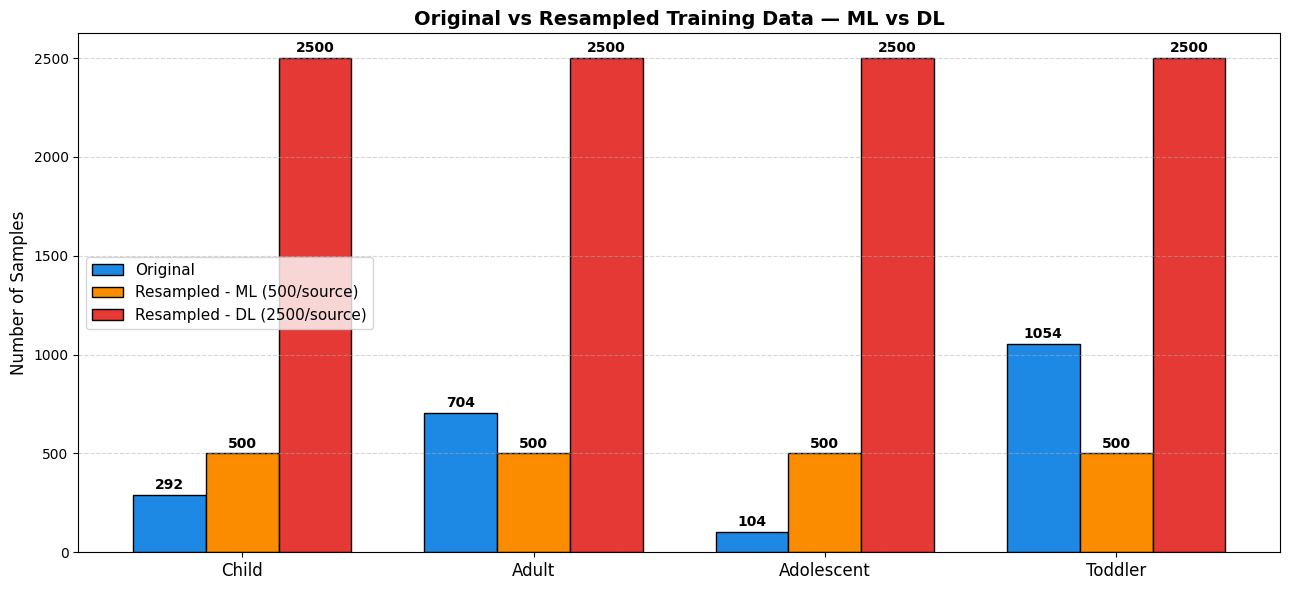

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
sources = ['Child', 'Adult', 'Adolescent', 'Toddler']
original_counts = [
    len(child[child['source'] == 'child']),
    len(adult[adult['source'] == 'adult']),
    len(adolescent[adolescent['source'] == 'adolescent']),
    len(screening[screening['source'] == 'screening']),
]
ml_resampled  = [500, 500, 500, 500]      # ML: 500 per source
dl_resampled  = [2500, 2500, 2500, 2500]  # DL: 2500 per source
x = np.arange(len(sources))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, original_counts, width, label='Original',
               color='#1E88E5', edgecolor='black')
bars2 = ax.bar(x,          ml_resampled,   width, label='Resampled - ML (500/source)',
               color='#FB8C00', edgecolor='black')
bars3 = ax.bar(x + width,  dl_resampled,   width, label='Resampled - DL (2500/source)',
               color='#E53935', edgecolor='black')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Original vs Resampled Training Data — ML vs DL', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_original_vs_resampled_ml_dl.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(train_resampled['source'].value_counts())
print("Total training rows:", len(train_resampled))
print("Test rows:", len(X_test))

source
child         500
adult         500
adolescent    500
screening     500
Name: count, dtype: int64
Total training rows: 2000
Test rows: 430


In [ ]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
print(X_train.dtypes)
print(X_train.isnull().sum())

A1_Score     int64
A2_Score     int64
A3_Score     int64
A4_Score     int64
A5_Score     int64
A6_Score     int64
A7_Score     int64
A8_Score     int64
A9_Score     int64
A10_Score    int64
age          int64
gender       int64
ethnicity    int64
jundice      int64
austim       int64
dtype: object
A1_Score     0
A2_Score     0
A3_Score     0
A4_Score     0
A5_Score     0
A6_Score     0
A7_Score     0
A8_Score     0
A9_Score     0
A10_Score    0
age          0
gender       0
ethnicity    0
jundice      0
austim       0
dtype: int64


In [ ]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("=== Random Forest Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

=== Random Forest Results ===
Test Accuracy: 0.9302325581395349

Confusion Matrix:
[[189  17]
 [ 13 211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       206
           1       0.93      0.94      0.93       224

    accuracy                           0.93       430
   macro avg       0.93      0.93      0.93       430
weighted avg       0.93      0.93      0.93       430


CV Scores: [0.9325 0.855  0.995  0.955  0.6175]
Mean CV Accuracy: 0.8710000000000001


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)
et.fit(X_train, y_train)
y_pred = et.predict(X_test)
print("=== Extra Trees Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cv_scores = cross_val_score(et, X_train, y_train, cv=5)
print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

=== Extra Trees Results ===
Test Accuracy: 0.9162790697674419

Confusion Matrix:
[[187  19]
 [ 17 207]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       206
           1       0.92      0.92      0.92       224

    accuracy                           0.92       430
   macro avg       0.92      0.92      0.92       430
weighted avg       0.92      0.92      0.92       430


CV Scores: [0.8925 0.9475 0.9875 0.9425 0.9125]
Mean CV Accuracy: 0.9364999999999999


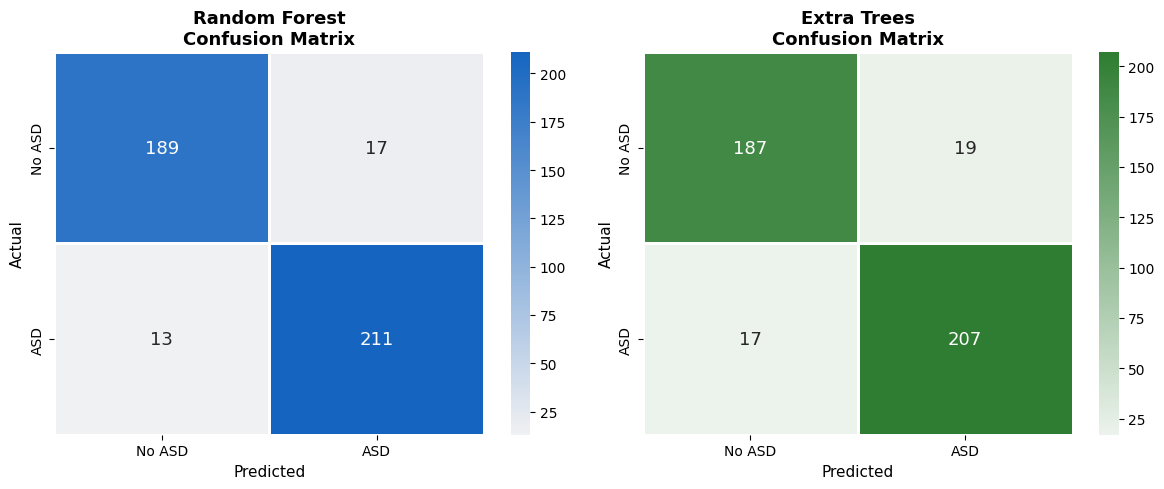

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tree_results = [
    ('Random Forest', rf, '#E3F2FD', '#1565C0'),
    ('Extra Trees',   et, '#E8F5E9', '#2E7D32'),
]
for ax, (name, model, bg, txt) in zip(axes, tree_results):

    cm = confusion_matrix(y_test, model.predict(X_test))


    cmap = sns.light_palette(txt, as_cmap=True)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=ax,
        xticklabels=['No ASD','ASD'],
        yticklabels=['No ASD','ASD'],
        linewidths=1,
        annot_kws={'size': 13}
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('fig_rf_et_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

print("=== AdaBoost Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(ada, X_train, y_train, cv=5)

print("\nCV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


=== AdaBoost Results ===
Test Accuracy: 1.0

Confusion Matrix:
[[206   0]
 [  0 224]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       206
           1       1.00      1.00      1.00       224

    accuracy                           1.00       430
   macro avg       1.00      1.00      1.00       430
weighted avg       1.00      1.00      1.00       430


CV Scores: [1.     0.93   1.     1.     0.9575]
Mean CV Accuracy: 0.9775


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters (XGBoost):", grid_xgb.best_params_)
print("Best CV Score (XGBoost):", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\n=== Tuned XGBoost Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

cv_scores_xgb = cross_val_score(best_xgb, X_train, y_train, cv=5)
print("\nCV Scores:", cv_scores_xgb)
print("Mean CV Accuracy:", np.mean(cv_scores_xgb))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.7}
Best CV Score (XGBoost): 0.9700000000000001

=== Tuned XGBoost Results ===
Test Accuracy: 0.986046511627907

Confusion Matrix:
[[202   4]
 [  2 222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       206
           1       0.98      0.99      0.99       224

    accuracy                           0.99       430
   macro avg       0.99      0.99      0.99       430
weighted avg       0.99      0.99      0.99       430


CV Scores: [0.995  0.9575 1.     0.9925 0.905 ]
Mean CV Accuracy: 0.9700000000000001


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

param_grid_lgbm = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1
)

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lgbm.fit(X_train, y_train)

print("Best Parameters (LightGBM):", grid_lgbm.best_params_)
print("Best CV Score (LightGBM):", grid_lgbm.best_score_)

best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm = best_lgbm.predict(X_test)

print("\n=== Tuned LightGBM Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

cv_scores_lgbm = cross_val_score(best_lgbm, X_train, y_train, cv=5)
print("\nCV Scores:", cv_scores_lgbm)
print("Mean CV Accuracy:", np.mean(cv_scores_lgbm))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters (LightGBM): {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.7}
Best CV Score (LightGBM): 0.9334999999999999

=== Tuned LightGBM Results ===
Test Accuracy: 0.9837209302325581

Confusion Matrix:
[[202   4]
 [  3 221]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       206
           1       0.98      0.99      0.98       224

    accuracy                           0.98       430
   macro avg       0.98      0.98      0.98       430
weighted avg       0.98      0.98      0.98       430


CV Scores: [0.98   0.92   1.     0.99   0.7775]
Mean CV Accuracy: 0.9334999999999999


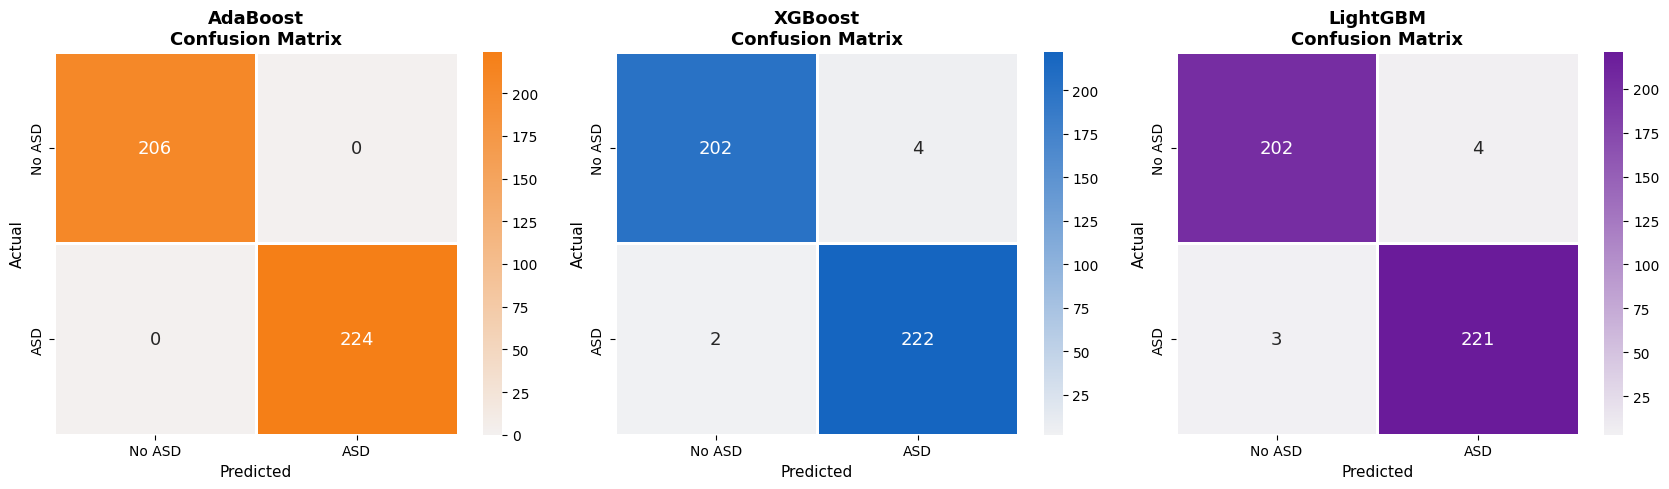

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
boost_results = [
    ('AdaBoost',   ada,          '#FFF9C4', '#F57F17'),
    ('XGBoost',    best_xgb,     '#E3F2FD', '#1565C0'),
    ('LightGBM',   best_lgbm,    '#F3E5F5', '#6A1B9A'),
]

for ax, (name, model, bg, txt) in zip(axes, boost_results):
    cm = confusion_matrix(y_test, model.predict(X_test))
    cmap = sns.light_palette(txt, as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No ASD','ASD'], yticklabels=['No ASD','ASD'],
                linewidths=1, annot_kws={'size': 13})
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('fig6_boosting_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# **DEEP Learning Using Tab Transformer**

In [ ]:
!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 15.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd

child_dl = pd.read_csv("Autism_Child_Data.csv")
adult_dl = pd.read_csv("Autism_Adult_Data.csv")
adolescent_dl = pd.read_csv("Autism_Adolescent_Data.csv")
screening_dl = pd.read_csv("Toddler Autism dataset July 2018.csv")

In [ ]:
import pandas as pd

screening_dl.rename(columns={
    'A1': 'A1_Score', 'A2': 'A2_Score', 'A3': 'A3_Score',
    'A4': 'A4_Score', 'A5': 'A5_Score', 'A6': 'A6_Score',
    'A7': 'A7_Score', 'A8': 'A8_Score', 'A9': 'A9_Score',
    'A10': 'A10_Score', 'Sex': 'gender', 'Ethnicity': 'ethnicity',
    'Jaundice': 'jundice', 'Family_mem_with_ASD': 'austim',
    'Class/ASD Traits ': 'Class/ASD'
}, inplace=True)

screening_dl["age"] = screening_dl["Age_Mons"] / 12

selected_cols = [
    'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score',
    'age','gender','ethnicity','jundice','austim','Class/ASD'
]

child_dl      = child_dl[selected_cols]
adult_dl      = adult_dl[selected_cols]
adolescent_dl = adolescent_dl[selected_cols]
screening_dl  = screening_dl[selected_cols]

for df_dl in [child_dl, adult_dl, adolescent_dl, screening_dl]:
    df_dl["Class/ASD"] = df_dl["Class/ASD"].astype(str).str.strip().str.upper()
    df_dl["ethnicity"] = df_dl["ethnicity"].replace("?", pd.NA)
    df_dl["ethnicity"] = df_dl["ethnicity"].fillna(df_dl["ethnicity"].mode()[0])
    for col in ["gender", "jundice", "austim"]:
        df_dl[col] = df_dl[col].astype(str).str.strip()
    df_dl.drop(df_dl[df_dl["age"] == "?"].index, inplace=True)
    df_dl["age"] = pd.to_numeric(df_dl["age"])
    df_dl["Class/ASD"] = df_dl["Class/ASD"].map({"NO": 0, "YES": 1})

print("Shapes after preprocessing:")
print("Child:", child_dl.shape)
print("Adult:", adult_dl.shape)
print("Adolescent:", adolescent_dl.shape)
print("Screening:", screening_dl.shape)


Shapes after preprocessing:
Child: (288, 16)
Adult: (702, 16)
Adolescent: (104, 16)
Screening: (1054, 16)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

child_dl['source']      = 'child'
adult_dl['source']      = 'adult'
adolescent_dl['source'] = 'adolescent'
screening_dl['source']  = 'screening'

combined_dl = pd.concat(
    [child_dl, adult_dl, adolescent_dl, screening_dl],
    ignore_index=True
)

X_dl = combined_dl.drop("Class/ASD", axis=1)
y_dl = combined_dl["Class/ASD"]

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42, stratify=y_dl
)

train_df_dl = X_train_dl.copy()
train_df_dl['Class/ASD'] = y_train_dl

TARGET_PER_SOURCE = 2500

resampled_groups_dl = []
for source in ['child', 'adult', 'adolescent', 'screening']:
    group = train_df_dl[train_df_dl['source'] == source]
    group_resampled = resample(
        group,
        replace=True,
        n_samples=TARGET_PER_SOURCE,
        random_state=42
    )
    resampled_groups_dl.append(group_resampled)

train_resampled_dl = pd.concat(resampled_groups_dl, ignore_index=True)

print(f"Total resampled training rows: {len(train_resampled_dl)}")
print("Rows per source:", train_resampled_dl['source'].value_counts().to_dict())
print("ASD distribution:\n", train_resampled_dl['Class/ASD'].value_counts())

train_resampled_dl = train_resampled_dl.drop('source', axis=1)
X_test_dl          = X_test_dl.drop('source', axis=1)

train_final_dl, val_dl = train_test_split(
    train_resampled_dl, test_size=0.2, random_state=42,
    stratify=train_resampled_dl['Class/ASD']
)

test_full_dl = X_test_dl.copy()
test_full_dl['Class/ASD'] = y_test_dl.values

num_cols_cast = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                 'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age']
for col in num_cols_cast:
    train_final_dl[col] = train_final_dl[col].astype('float32')
    val_dl[col]         = val_dl[col].astype('float32')
    test_full_dl[col]   = test_full_dl[col].astype('float32')

print(f"\nTrain : {len(train_final_dl)} rows")
print(f"Val   : {len(val_dl)} rows")
print(f"Test  : {len(test_full_dl)} rows")


Total resampled training rows: 10000
Rows per source: {'child': 2500, 'adult': 2500, 'adolescent': 2500, 'screening': 2500}
ASD distribution:
 Class/ASD
1    5112
0    4888
Name: count, dtype: int64

Train : 8000 rows
Val   : 2000 rows
Test  : 430 rows


In [ ]:
from pytorch_tabular import TabularModel
from pytorch_tabular.models import TabTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

cat_cols = ['gender', 'ethnicity', 'jundice', 'austim']
num_cols = [
    'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age'
]

data_config = DataConfig(
    target=['Class/ASD'],
    continuous_cols=num_cols,
    categorical_cols=cat_cols,
)

trainer_config = TrainerConfig(
    max_epochs=50,
    batch_size=64,
    early_stopping="valid_loss",
    early_stopping_patience=10,
    checkpoints="valid_loss",
    load_best=True,
)

optimizer_config = OptimizerConfig(
    optimizer="Adam",
    lr_scheduler="ReduceLROnPlateau"
)

model_config = TabTransformerConfig(
    task="classification",
    num_heads=8,
    num_attn_blocks=6,
    attn_dropout=0.1,
    ff_dropout=0.1,
    metrics=["accuracy"],
)

print("Configs defined successfully!")


Configs defined successfully!


In [ ]:
tab_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

tab_model.fit(
    train=train_final_dl,
    validation=val_dl
)

print("Training complete!")


2026-05-26 04:58:06,530 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-05-26 04:58:06,556 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-05-26 04:58:06,570 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-05-26 04:58:06,629 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: TabTransformerModel
2026-05-26 04:58:06,745 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Exp

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ TabTransformerBackbone │  271 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer       │    960 │ train │     0 │
│ 2 │ _head            │ LinearHead             │    280 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss       │      0 │ train │     0 │
└───┴──────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 272 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1.090                                                                      
Modules in train mode: 127                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

2026-05-26 05:05:07,044 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-05-26 05:05:07,046 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


Training complete!


In [ ]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             f1_score, precision_score, recall_score)
import numpy as np

pred_df   = tab_model.predict(test_full_dl)
y_pred_dl = pred_df['Class/ASD_prediction'].values
y_true_dl = test_full_dl['Class/ASD'].values

prob_col = [c for c in pred_df.columns if 'probability' in c.lower() or c.endswith('_1')]
auc = roc_auc_score(y_true_dl, pred_df[prob_col[-1]].values) if prob_col else None

print("=" * 52)
print("   Tab Transformer — Test Set Performance (10000 rows resampled)")
print("=" * 52)
print(f"  Accuracy  : {accuracy_score(y_true_dl, y_pred_dl):.4f}")
print(f"  Precision : {precision_score(y_true_dl, y_pred_dl):.4f}")
print(f"  Recall    : {recall_score(y_true_dl, y_pred_dl):.4f}")
print(f"  F1-Score  : {f1_score(y_true_dl, y_pred_dl):.4f}")
if auc is not None:
    print(f"  ROC-AUC   : {auc:.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_true_dl, y_pred_dl))
print()
print("Classification Report:")
print(classification_report(y_true_dl, y_pred_dl, target_names=["No ASD", "ASD"]))


   Tab Transformer — Test Set Performance (10000 rows resampled)
  Accuracy  : 0.9814
  Precision : 0.9865
  Recall    : 0.9777
  F1-Score  : 0.9821
  ROC-AUC   : 0.9939

Confusion Matrix:
[[203   3]
 [  5 219]]

Classification Report:
              precision    recall  f1-score   support

      No ASD       0.98      0.99      0.98       206
         ASD       0.99      0.98      0.98       224

    accuracy                           0.98       430
   macro avg       0.98      0.98      0.98       430
weighted avg       0.98      0.98      0.98       430



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
from pytorch_tabular import TabularModel
from pytorch_tabular.models import TabTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

cv_full = train_resampled_dl.copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "roc_auc": []}

cat_cols_cv = ['gender', 'ethnicity', 'jundice', 'austim']
num_cols_cv = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
               'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age']

for fold, (train_idx, val_idx) in enumerate(
        skf.split(cv_full, cv_full['Class/ASD']), start=1):

    print(f"\n{'─'*42}")
    print(f"  Fold {fold} / 5  |  train={len(train_idx)}  val={len(val_idx)}")
    print(f"{'─'*42}")

    fold_train = cv_full.iloc[train_idx].reset_index(drop=True)
    fold_val   = cv_full.iloc[val_idx].reset_index(drop=True)

    for col in num_cols_cv:
        fold_train[col] = fold_train[col].astype('float32')
        fold_val[col]   = fold_val[col].astype('float32')

    dc = DataConfig(target=['Class/ASD'],
                    continuous_cols=num_cols_cv,
                    categorical_cols=cat_cols_cv)

    tc = TrainerConfig(max_epochs=30, batch_size=64,
                       early_stopping="valid_loss",
                       early_stopping_patience=5,
                       checkpoints="valid_loss",
                       load_best=True)

    oc = OptimizerConfig(optimizer="Adam", lr_scheduler="ReduceLROnPlateau")

    mc = TabTransformerConfig(task="classification",
                              num_heads=4, num_attn_blocks=3,
                              attn_dropout=0.1, ff_dropout=0.1,
                              metrics=["accuracy"])

    m = TabularModel(data_config=dc, model_config=mc,
                     optimizer_config=oc, trainer_config=tc)
    m.fit(train=fold_train, validation=fold_val)

    pred = m.predict(fold_val)
    y_p  = pred['Class/ASD_prediction'].values
    y_t  = fold_val['Class/ASD'].values

    prob_c = [c for c in pred.columns if 'probability' in c.lower() or c.endswith('_1')]
    auc_v  = roc_auc_score(y_t, pred[prob_c[-1]].values) if prob_c else None

    acc  = accuracy_score(y_t, y_p)
    prec = precision_score(y_t, y_p, zero_division=0)
    rec  = recall_score(y_t, y_p, zero_division=0)
    f1   = f1_score(y_t, y_p, zero_division=0)

    cv_metrics["accuracy"].append(acc)
    cv_metrics["precision"].append(prec)
    cv_metrics["recall"].append(rec)
    cv_metrics["f1"].append(f1)
    if auc_v is not None:
        cv_metrics["roc_auc"].append(auc_v)

    auc_str = f"  AUC={auc_v:.4f}" if auc_v is not None else ""
    print(f"  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}{auc_str}")

print("\n" + "=" * 52)
print("  5-Fold CV Summary — TabTransformer (DL)")
print("=" * 52)
for metric, vals in cv_metrics.items():
    if vals:
        print(f"  {metric:12s}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")


Epoch 29/29 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125/125 0:00:05 • 0:00:00 22.98it/s v_num: 5.000 train_loss: 0.134    
                                                                                 valid_loss: 0.042 valid_accuracy: 
                                                                                 0.991 train_accuracy: 0.980       

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


2026-05-26 05:21:09,370 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-05-26 05:21:09,371 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model


  Acc=0.9925  Prec=0.9932  Rec=0.9922  F1=0.9927  AUC=0.9988

  5-Fold CV Summary — TabTransformer (DL)
  accuracy    : mean=0.9932  std=0.0009
  precision   : mean=0.9947  std=0.0033
  recall      : mean=0.9920  std=0.0019
  f1          : mean=0.9933  std=0.0008
  roc_auc     : mean=0.9989  std=0.0003


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

tt_cv_acc  = float(np.mean(cv_metrics["accuracy"]))
tt_cv_f1   = float(np.mean(cv_metrics["f1"]))
tt_cv_std  = float(np.std(cv_metrics["accuracy"]))

tt_test_acc  = accuracy_score(y_true_dl, y_pred_dl)
tt_test_f1   = f1_score(y_true_dl, y_pred_dl)
tt_test_prec = precision_score(y_true_dl, y_pred_dl)
tt_test_rec  = recall_score(y_true_dl, y_pred_dl)

summary_dl = pd.DataFrame({
    "Model"           : ["TabTransformer (DL)"],
    "Resample Rows"   : [10000],
    "CV Folds"        : [5],
    "CV Acc (mean)"   : [round(tt_cv_acc,  4)],
    "CV Acc (std)"    : [round(tt_cv_std,  4)],
    "CV F1  (mean)"   : [round(tt_cv_f1,   4)],
    "Test Acc"        : [round(tt_test_acc, 4)],
    "Test Precision"  : [round(tt_test_prec, 4)],
    "Test Recall"     : [round(tt_test_rec,  4)],
    "Test F1"         : [round(tt_test_f1,   4)],
})

print("=" * 75)
print("       Deep Learning Model Summary  —  resampled to 10000 rows")
print("=" * 75)
print(summary_dl.to_string(index=False))


       Deep Learning Model Summary  —  resampled to 10000 rows
              Model  Resample Rows  CV Folds  CV Acc (mean)  CV Acc (std)  CV F1  (mean)  Test Acc  Test Precision  Test Recall  Test F1
TabTransformer (DL)          10000         5         0.9932        0.0009         0.9933    0.9814          0.9865       0.9777   0.9821


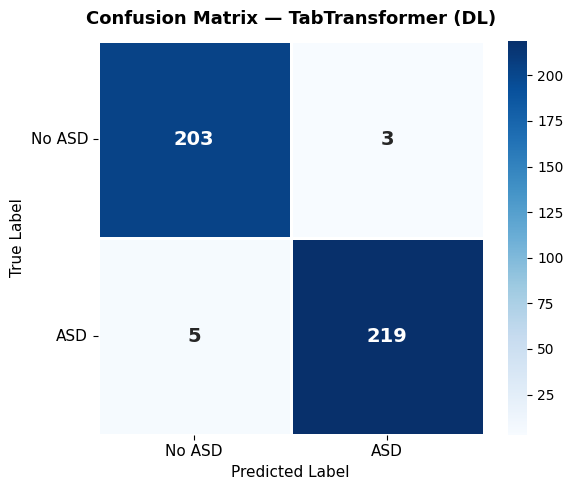

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_dl, y_pred_dl)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues", linewidths=0.8, linecolor="white",
            xticklabels=["No ASD", "ASD"],
            yticklabels=["No ASD", "ASD"],
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)

ax.set_title("Confusion Matrix — TabTransformer (DL)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="x", labelsize=11, rotation=0)
ax.tick_params(axis="y", labelsize=11, rotation=0)

plt.tight_layout()
plt.savefig("cm_tabtransformer.png", dpi=150, bbox_inches="tight")
plt.show()

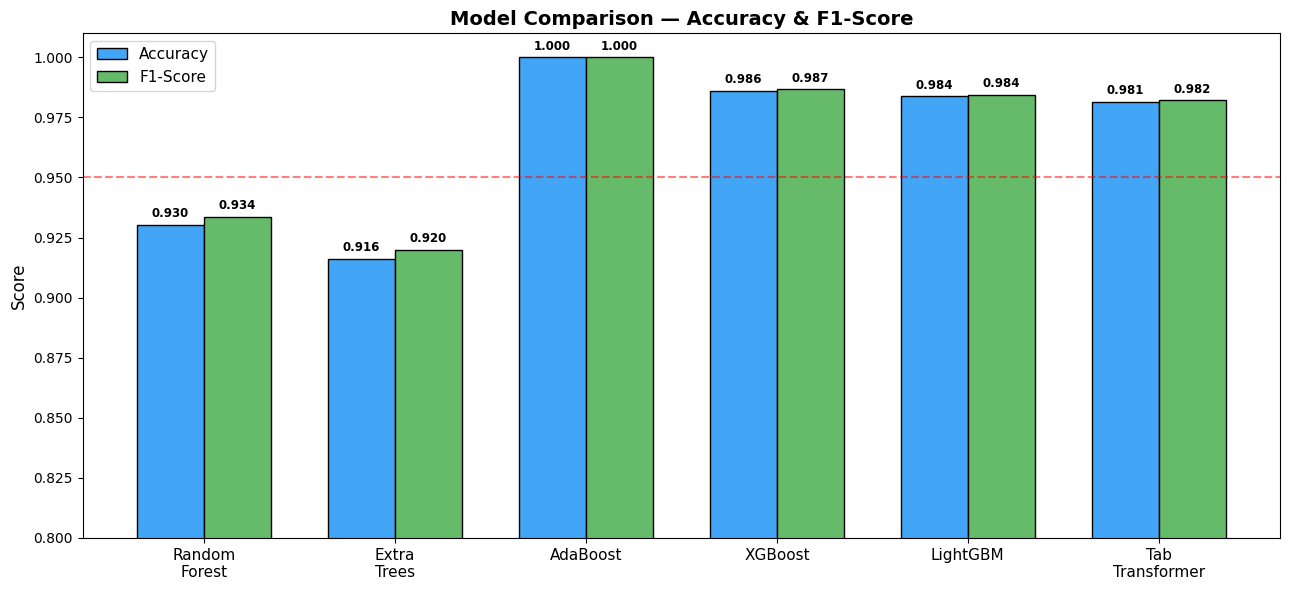

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

models = ['Random\nForest', 'Extra\nTrees', 'AdaBoost', 'XGBoost', 'LightGBM', 'Tab\nTransformer']
accuracies = [
    accuracy_score(y_test, rf.predict(X_test)),
    accuracy_score(y_test, et.predict(X_test)),
    accuracy_score(y_test, ada.predict(X_test)),
    accuracy_score(y_test, best_xgb.predict(X_test)),
    accuracy_score(y_test, best_lgbm.predict(X_test)),
    accuracy_score(y_true_dl, y_pred_dl),
]
f1_scores = [
    f1_score(y_test, rf.predict(X_test)),
    f1_score(y_test, et.predict(X_test)),
    f1_score(y_test, ada.predict(X_test)),
    f1_score(y_test, best_xgb.predict(X_test)),
    f1_score(y_test, best_lgbm.predict(X_test)),
    f1_score(y_true_dl, y_pred_dl),
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',  color='#42A5F5', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1-Score',  color='#66BB6A', edgecolor='black')

ax.set_ylim(0.80, 1.01)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Accuracy & F1-Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='0.95 threshold')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

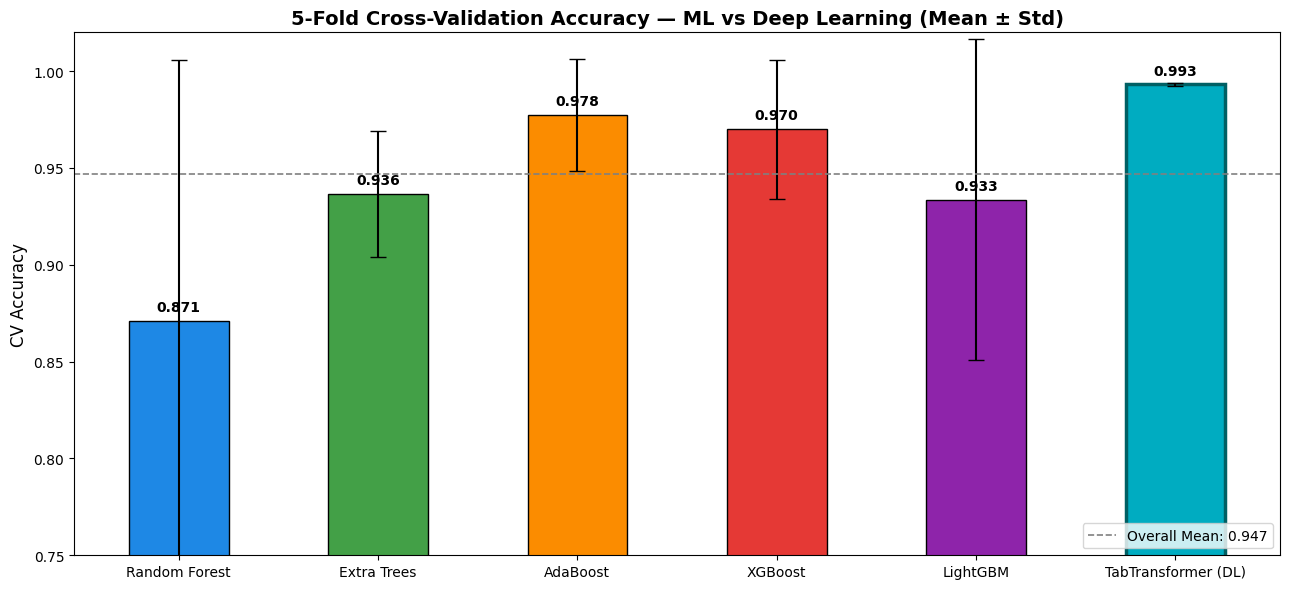

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

rf_cv   = cross_val_score(rf,        X_train, y_train, cv=5)
et_cv   = cross_val_score(et,        X_train, y_train, cv=5)
ada_cv  = cross_val_score(ada,       X_train, y_train, cv=5)
xgb_cv  = cross_val_score(best_xgb,  X_train, y_train, cv=5)
lgbm_cv = cross_val_score(best_lgbm, X_train, y_train, cv=5)

dl_cv_acc = cv_metrics["accuracy"]

model_names = ['Random Forest', 'Extra Trees', 'AdaBoost',
               'XGBoost', 'LightGBM', 'TabTransformer (DL)']

cv_means = [np.mean(rf_cv), np.mean(et_cv), np.mean(ada_cv),
            np.mean(xgb_cv), np.mean(lgbm_cv), np.mean(dl_cv_acc)]
cv_stds  = [np.std(rf_cv),  np.std(et_cv),  np.std(ada_cv),
            np.std(xgb_cv),  np.std(lgbm_cv),  np.std(dl_cv_acc)]

colors = ['#1E88E5','#43A047','#FB8C00','#E53935','#8E24AA','#00ACC1']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(model_names, cv_means, yerr=cv_stds, color=colors,
              edgecolor='black', capsize=6, width=0.5)

ax.set_ylim(0.75, 1.02)
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_title('5-Fold Cross-Validation Accuracy — ML vs Deep Learning (Mean ± Std)',
             fontsize=14, fontweight='bold')
ax.axhline(y=np.mean(cv_means), color='gray', linestyle='--',
           linewidth=1.2, label=f'Overall Mean: {np.mean(cv_means):.3f}')
ax.legend(fontsize=10)

for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

bars[-1].set_linewidth(2.5)
bars[-1].set_edgecolor('#006064')

plt.tight_layout()
plt.savefig('fig9_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9190/620127623.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask_numeric = df_params.applymap(lambda x: 0 if x == "-" else 1).astype(float)


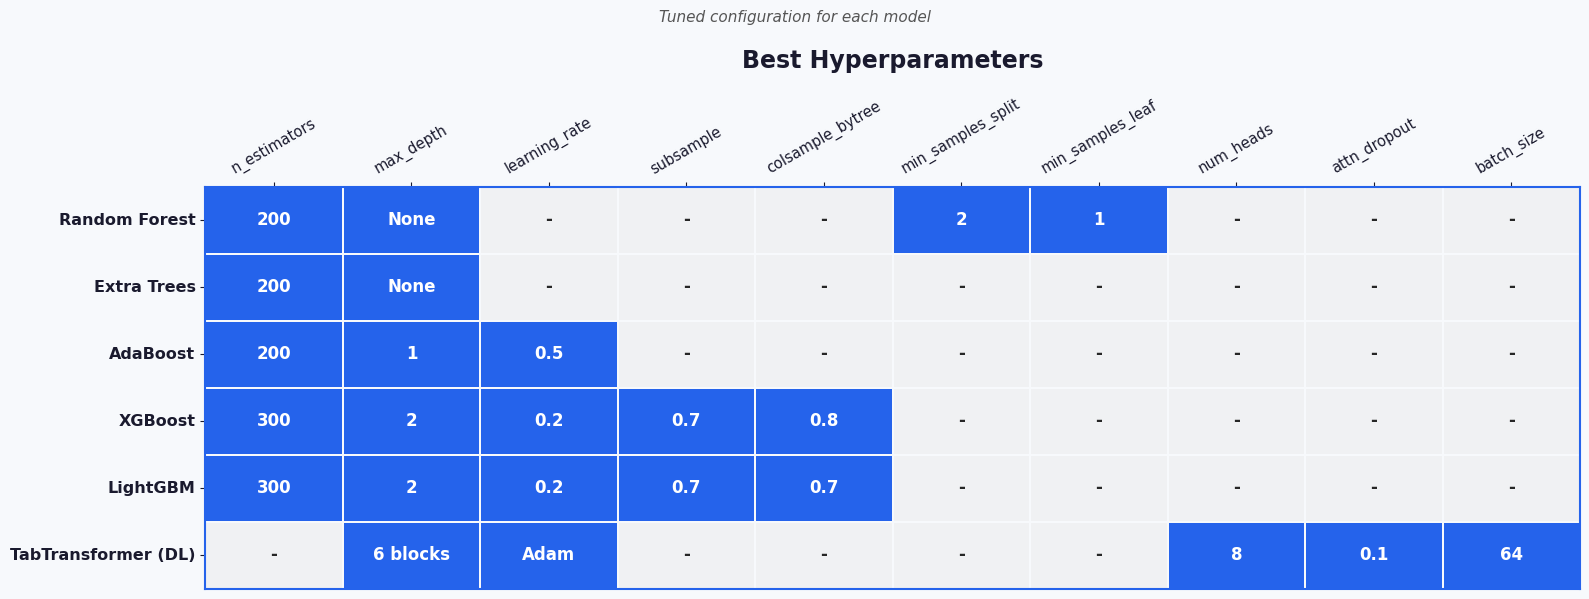

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

params = {
    "n_estimators"     : [200, 200, 200,
                          grid_xgb.best_params_["n_estimators"],
                          grid_lgbm.best_params_["n_estimators"],
                          "-"],
    "max_depth"        : ["None", "None", "1",
                          grid_xgb.best_params_["max_depth"],
                          grid_lgbm.best_params_["max_depth"],
                          "6 blocks"],
    "learning_rate"    : ["-", "-", "0.5",
                          grid_xgb.best_params_["learning_rate"],
                          grid_lgbm.best_params_["learning_rate"],
                          "Adam"],
    "subsample"        : ["-", "-", "-",
                          grid_xgb.best_params_["subsample"],
                          grid_lgbm.best_params_["subsample"],
                          "-"],
    "colsample_bytree" : ["-", "-", "-",
                          grid_xgb.best_params_["colsample_bytree"],
                          grid_lgbm.best_params_["colsample_bytree"],
                          "-"],
    "min_samples_split": ["2", "-", "-", "-", "-", "-"],
    "min_samples_leaf" : ["1", "-", "-", "-", "-", "-"],
    "num_heads"        : ["-", "-", "-", "-", "-", "8"],
    "attn_dropout"     : ["-", "-", "-", "-", "-", "0.1"],
    "batch_size"       : ["-", "-", "-", "-", "-", "64"],
}

models = ["Random Forest", "Extra Trees", "AdaBoost",
          "XGBoost", "LightGBM", "TabTransformer (DL)"]

df_params = pd.DataFrame(params, index=models)
mask_numeric = df_params.applymap(lambda x: 0 if x == "-" else 1).astype(float)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

sns.heatmap(mask_numeric, annot=df_params, fmt="",
            cmap=sns.light_palette("#2563EB", as_cmap=True),
            linewidths=1.2, linecolor="#F7F9FC",
            cbar=False, ax=ax,
            annot_kws={"size": 12, "weight": "bold"})

ax.set_title("Best Hyperparameters", fontsize=17,
             fontweight="bold", pad=20, color="#1a1a2e",
             loc="center")
fig.text(0.5, 0.97, "Tuned configuration for each model",
         ha="center", fontsize=11, color="#555555", style="italic")

ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=10.5, rotation=30, colors="#1a1a2e")
ax.tick_params(axis="y", labelsize=11.5, rotation=0,  colors="#1a1a2e")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#2563EB")
    spine.set_linewidth(1.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("best_params_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()